# Simulated Energy Detector for ADS-B Data
This notebook aims to measure the the average energy of ADS-B signals using a sliding window. The sliding window loop aims to simulate how the RFSoC will be receiving signals in production (not all at once). For full thresholding, a hypothesis test will be conducted on the Gaussian noise measured from the RFSoC.

In [1]:
import pickle

with open("samples.pkl", "rb") as f:
    X = pickle.load(f)

print("Loaded data")

Loaded data


814


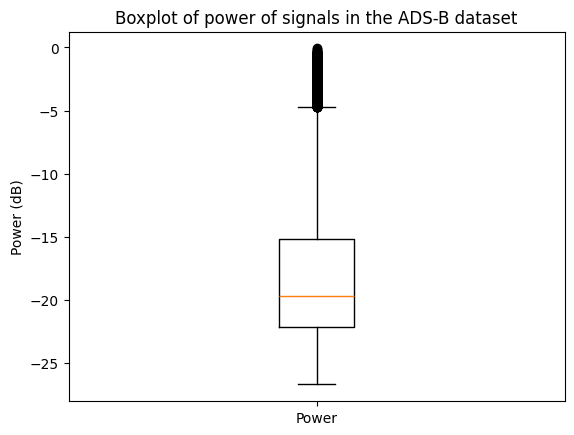

123


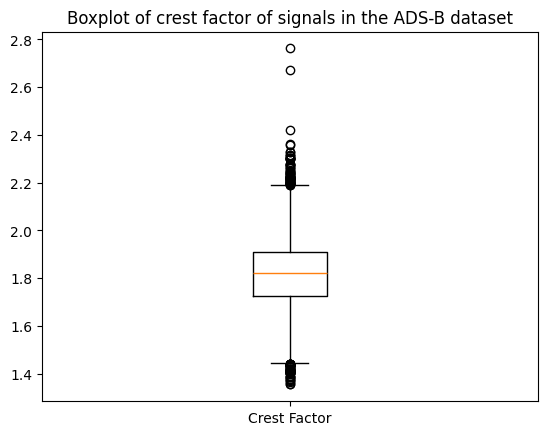

525


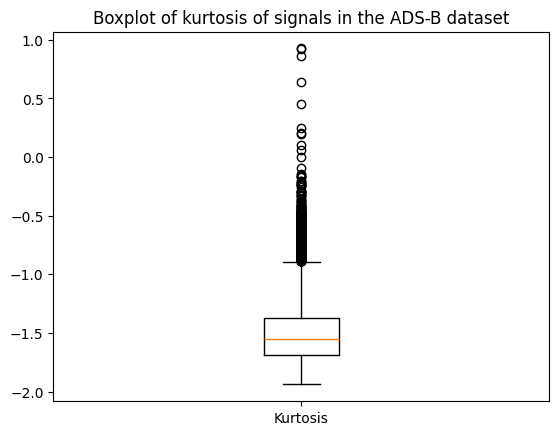

642


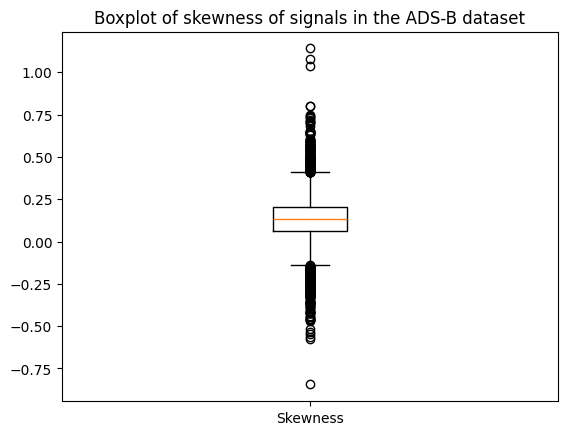

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import get_features as feat

window_size = 128
update_weight = 0.3

stats = {
    "power_db": [],
    "crest_factor": [],
    "kurtosis": [],
    "skewness": []
}

for signal in X:
    # Initialise feature estimates
    power_estimate_db = 0
    crest_factor_estimate = 0
    kurtosis_estimate = 0
    skewness_estimate = 0
    
    # Calculate the power using a sliding window
    sum_of_squares = 0
    iq = signal[0] + 1j*signal[1]
    mag_squared = signal[0]**2 + signal[1]**2
    for idx in range(len(mag_squared)):
        # Add the next sample
        sum_of_squares += mag_squared[idx]
        
        # If the current window is full, remove the tail sample and calculate the power
        if idx >= window_size:
            sum_of_squares -= mag_squared[idx - window_size]
            power_estimate_db = (1 - update_weight)*power_estimate_db + update_weight*10*np.log10(sum_of_squares/window_size)

        # Once power detector threshold has been determined, it will be included here
        if idx >= window_size and idx%(window_size/2) == 0:
            features = feat.get_td_features(iq[(idx - window_size):idx])
            crest_factor_estimate = (1 - update_weight)*crest_factor_estimate + update_weight*features["crest_factor"]
            kurtosis_estimate = (1 - update_weight)*kurtosis_estimate + update_weight*features["kurtosis"]
            skewness_estimate = (1 - update_weight)*skewness_estimate + update_weight*features["skewness"]
    
    stats["power_db"].append(power_estimate_db)
    stats["crest_factor"].append(crest_factor_estimate)
    stats["kurtosis"].append(kurtosis_estimate)
    stats["skewness"].append(skewness_estimate)

bp = plt.boxplot(stats["power_db"], tick_labels = ["Power"])
plt.title("Boxplot of power of signals in the ADS-B dataset")
plt.ylabel("Power (dB)")
#plt.savefig("avg_power.png")
outlier_count = len(bp['fliers'][0].get_ydata())
print(outlier_count)
plt.show()

bp = plt.boxplot(stats["crest_factor"], tick_labels = ["Crest Factor"])
plt.title("Boxplot of crest factor of signals in the ADS-B dataset")
#plt.savefig("crest_factor.png")
outlier_count = len(bp['fliers'][0].get_ydata())
print(outlier_count)
plt.show()

bp = plt.boxplot(stats["kurtosis"], tick_labels = ["Kurtosis"])
plt.title("Boxplot of kurtosis of signals in the ADS-B dataset")
#plt.savefig("kurtosis.png")
outlier_count = len(bp['fliers'][0].get_ydata())
print(outlier_count)
plt.show()

bp = plt.boxplot(stats["skewness"], tick_labels = ["Skewness"])
plt.title("Boxplot of skewness of signals in the ADS-B dataset")
#plt.savefig("skewness.png")
outlier_count = len(bp['fliers'][0].get_ydata())
print(outlier_count)
plt.show()